1.	Model kurma
2.	Model değerlendirme
3.	Uygulama

Eğitim seti (Training Set) modelin öğrenmesi için, test seti (Test Set) ise performans analizi için kullanılır."

In [1]:
import pandas as pd
data=pd.read_csv("insurance.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


data.info(), bir Pandas DataFrame hakkında genel bir özet sunan en temel "tanı" komutudur. Veriyi ilk yüklediğinizde, içinde ne olduğunu ve yapısal bir sorun olup olmadığını anlamak için bu satırı kullanırsınız.

1. Veri Yapısı ve İndeks Bilgisi

Verinin bir Pandas DataFrame olup olmadığını doğrular.

Toplam kaç satır (girdi) olduğunu ve bu satırların indeks aralığını (örneğin: RangeIndex: 500 entries, 0 to 499) gösterir.

2. Sütun Detayları (Column Information)

Her bir sütun için şu bilgileri alt alta listeler:

Column Name: Sütunun adı.

Non-Null Count: O sütunda kaç tane boş olmayan (dolu) değer olduğu.

İpucu: Eğer toplam satır sayınız 500 ama bir sütunda "450 non-null" yazıyorsa, o sütunda 50 tane eksik veri olduğunu anında anlarsınız.

Dtype: Veri tipi (tamsayı, ondalıklı sayı, obje/metin, tarih vb.).

3. Bellek Kullanımı (Memory Usage)

Veri setinin bilgisayarınızın RAM'inde ne kadar yer kapladığını gösterir. Büyük veri setleriyle çalışırken sistemin kilitlenmemesi için bu bilgi hayati önem taşır.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


data.isnull() komutu, veri çerçevenizdeki (DataFrame) her bir hücreyi kontrol eder:

Eğer hücre boşsa (NaN, None, NaT), o hücre için True değerini döndürür.

Eğer hücre doluysa, False değerini döndürür.

Sonuç olarak, orijinal verinizle aynı boyutta, sadece True ve Falselardan oluşan bir tablo elde edersiniz.

In [ ]:
data.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


Eğer hangi sütunda ne kadar eksik olduğunu değil de, tüm veri setinde toplam kaç tane boş hücre olduğunu merak ediyorsak şu şekilde kullanabiliriz.
 data.isnull().sum()

In [ ]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


data.dtypes komutu, veri çerçevenizdeki (DataFrame) her bir sütunun hangi veri tipine sahip olduğunu gösteren bir özelliktir (attribute).

Bir veri setinde sayıların gerçekten "sayı" olarak mı, yoksa yanlışlıkla "metin" (string) olarak mı kaydedildiğini anlamak için bu komutu kullanırız.

1. Ne Anlatır?

Bu komutu çalıştırdığımızda karşımıza sütun isimleri ve yanlarında veri tipleri gelir. En sık karşılaşacağımız tipler şunlardır:

int64: Tam sayılar (Örn: 25, 100).

float64: Ondalıklı sayılar (Örn: 15.5, 0.99).

object: Genellikle metinler (string) veya karışık tipler.

bool: Doğru/Yanlış (True/False) değerleri.

datetime64: Tarih ve saat bilgileri.

In [ ]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
data["sex"] = data["sex"].astype("category")
data["smoker"] = data["smoker"].astype("category")
data["region"] = data["region"].astype("category")

In [ ]:
data.dtypes

,0
age,int64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


1. data.describe() Bölümü

Bu komut, sayısal sütunlarınızın merkezi eğilimlerini ve dağılımını hesaplar. Varsayılan olarak şu değerleri verir:

count: Boş olmayan (non-null) veri sayısı.

mean: Aritmetik ortalama.

std: Standart sapma (verilerin ortalamadan ne kadar uzaklaştığı).

min / max: En küçük ve en büyük değerler.

%25, %50, %75: Çeyreklikler (Verinin dağılımını anlamak için; örneğin %50 aynı zamanda medyandır).

2. .T (Transpose) Bölümü

Normalde describe() çıktısında istatistikler (mean, std vb.) satırlarda, sütun isimleri ise yukarıda (sütunlarda) yer alır. Veri setinizde çok fazla sütun varsa, tablo sağa doğru çok uzar ve okumak imkansız hale gelir.

.T eklediğimizde satırlarla sütunların yerini değiştiririz.

Sütun isimleriniz sol tarafa (satırlara) gelir, istatistiksel hesaplamalar ise yukarıya dizilir.

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


Bu kod satırı, verinizi "sigara içme durumuna göre" gruplandırarak belirli özelliklerin (yaş, vücut kitle indeksi, çocuk sayısı ve masraflar) ortalamasını hesaplar. Veri setindeki sigara içen ve içmeyenler arasındaki farkları net bir şekilde karşılaştırmanızı sağlar.

İşlemi adım adım inceleyelim:

1. Kodun Parçalanmış Analizi

data.groupby("smoker"): Veriyi "smoker" (sigara içenler) sütununa göre iki ana gruba ayırır: Yes (Evet) ve No (Hayır).

[["age", "bmi", "children", "charges"]]: Gruplandırma yapıldıktan sonra sadece bu dört sütunla ilgilenmek istediğinizi belirtirsiniz. (Böylece cinsiyet veya bölge gibi gereksiz sütunlar tabloda kalabalık yapmaz).

.mean(): Her bir grup (içenler ve içmeyenler) için bu sütunların aritmetik ortalamasını hesaplar.

.round(2): Sonuçları virgülden sonra iki basamağa yuvarlar, böylece tablo daha temiz görünür.

In [ ]:
smoke_data = data.groupby("smoker")[["age", "bmi", "children", "charges"]].mean().round(2)
smoke_data

/tmp/ipykernel_4247/1874129463.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoke_data = data.groupby("smoker")[["age", "bmi", "children", "charges"]].mean().round(2)


,age,bmi,children,charges
smoker,,,,
no,39.39,30.65,1.09,8434.27
yes,38.51,30.71,1.11,32050.23


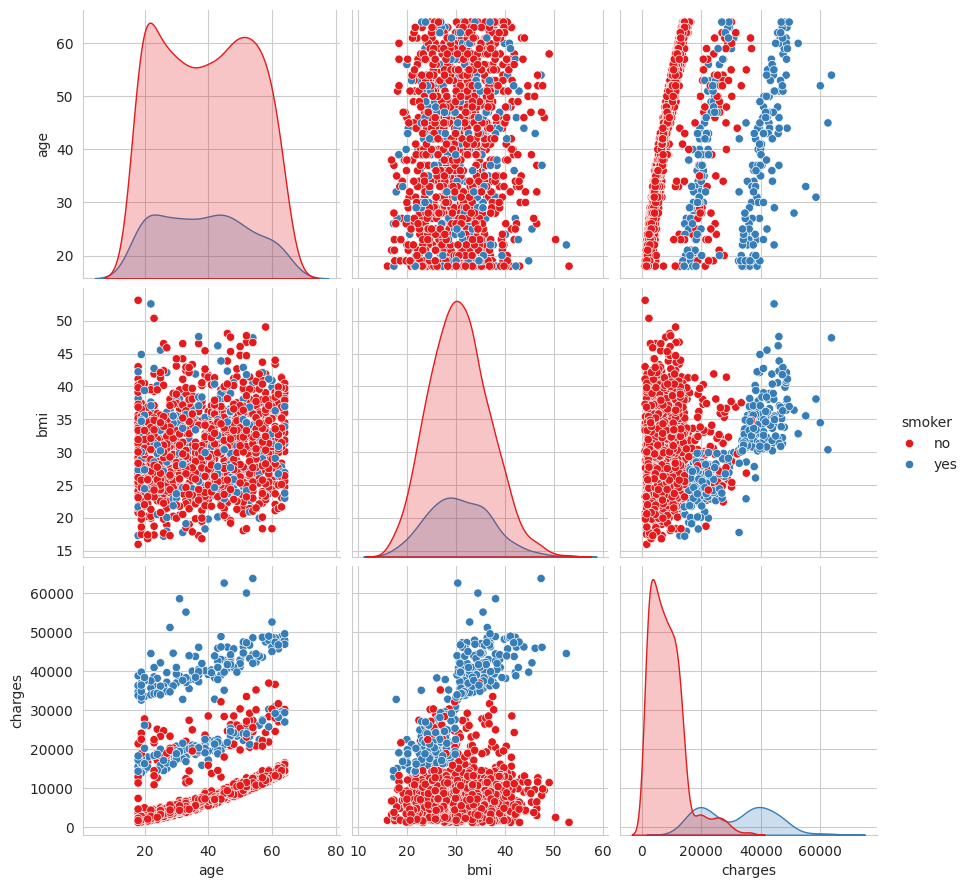

In [ ]:
import seaborn as sns

sns.set_style("whitegrid")

sns.pairplot(data[["age", "bmi", "charges", "smoker"]],
             hue = "smoker",
             height = 3,
             palette = "Set1")

<Axes: >

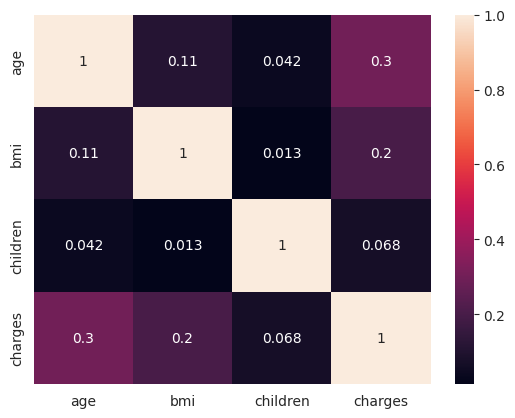

In [ ]:
sns.heatmap(data.corr(numeric_only=True), annot =True)

In [ ]:
data.dtypes

,0
age,int64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


In [ ]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
data=pd.get_dummies(data)

In [ ]:
data.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [ ]:
y=data['charges']

In [ ]:
X=data.drop('charges',axis=1)

In [ ]:
# Bağımsız değişkenleri (X) hazırlama (Hedef değişken olan 'charges' sütununu çıkarıyoruz)
X = data.drop("charges", axis = 1)

# Veriyi eğitim ve test setlerine ayırmak için gerekli kütüphaneyi içe aktarma
from sklearn.model_selection import train_test_split

# Veriyi %80 eğitim, %20 test olacak şekilde bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.80, random_state=1)

# Lineer Regresyon modelini içe aktarma
from sklearn.linear_model import LinearRegression

# Model nesnesini oluşturma
lr = LinearRegression()

# Modeli eğitim verileri (X_train ve y_train) ile eğitme
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
round(lr.score(X_test, y_test), 3)

0.762

In [ ]:
round(lr.score(X_train, y_train), 3)

0.748

In [ ]:
# Eğitilen model ile test verileri üzerinde tahmin yapma
y_pred = lr.predict(X_test)

# Hata metriklerini hesaplamak için gerekli kütüphaneyi içe aktarma
from sklearn.metrics import mean_squared_error

# Matematiksel işlemler için math kütüphanesini içe aktarma
import math

# Kök Ortalama Kare Hata (RMSE) hesaplama
math.sqrt(mean_squared_error(y_test, y_pred))

5956.454717976428

In [ ]:
data_new=X_train[:1]

In [ ]:
data_new

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
216,53,26.6,0,True,False,True,False,False,True,False,False


In [ ]:
lr.predict(data_new)

array([10508.41885042])

In [ ]:
y_train[:1]

,charges
216,10355.641
